# Sentiment Analysis of Product Reviews
## Notebook 3: Model Explainability & Visualisations

## Required Imports

In [16]:
import os
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
PLOTS_DIR      = "plots"
SENTIMENT_ORDER = ["Negative", "Neutral", "Positive"]
PALETTE = {"Negative": "#E74C3C", "Neutral": "#F39C12", "Positive": "#27AE60"}

## SECTION 7 – MODEL EXPLAINABILITY

In [10]:
def get_feature_names(tfidf: TfidfVectorizer, selector, n_ling: int = 4) -> list:
    """Reconstruct feature names after SelectKBest."""
    ling_names = ["sentence_length", "punctuation_density",
                  "avg_word_length", "has_negation"]
    all_names  = list(tfidf.get_feature_names_out()) + ling_names[:n_ling]
    mask       = selector.get_support()
    return [all_names[i] for i, keep in enumerate(mask) if keep]


def explain_model(model, model_name: str, feature_names: list,
                  label_names: list, top_n: int = 20):
    """
    Extract top discriminating features for each sentiment class.
    Works for Logistic Regression and Linear SVM (coefficient-based).
    """
    print(f"\n{'='*60}")
    print("SECTION 7: MODEL EXPLAINABILITY")
    print(f"{'='*60}")
    print(f"  ► Model: {model_name}")

    # Unwrap CalibratedClassifierCV
    base = model.estimator if hasattr(model, "estimator") else model

    if not hasattr(base, "coef_"):
        print("  ► Skipping (no coef_ attribute — Gradient Boosting / NB)")
        return {}

    coef = base.coef_           # shape: (n_classes, n_features)
    top_features = {}

    for i, cls in enumerate(label_names):
        if coef.shape[0] == 1:  # binary OvR
            c = coef[0] if i == 1 else -coef[0]
        else:
            c = coef[i]

        top_idx     = np.argsort(c)[::-1][:top_n]
        bottom_idx  = np.argsort(c)[:top_n]

        top_features[cls] = {
            "positive": [(feature_names[j], c[j]) for j in top_idx],
            "negative": [(feature_names[j], c[j]) for j in bottom_idx],
        }
        print(f"\n  Class: {cls}")
        print(f"    Top {top_n} positive features:")
        for feat, score in top_features[cls]["positive"][:10]:
            print(f"      {feat:<35s}  {score:+.4f}")

    return top_features

In [11]:
# Example usage — assumes fitted_models, tfidf, sel_chi2, le are available from Notebook 2
# best_model   = fitted_models[best_model_name]
# feat_names   = get_feature_names(tfidf, sel_chi2)
# top_features = explain_model(
#     best_model, best_model_name, feat_names,
#     label_names=list(le.classes_)
# )

## SECTION 8 – VISUALISATIONS (Remaining Plots)

In [12]:
def save_plot(fig, name: str):
    os.makedirs(PLOTS_DIR, exist_ok=True)
    path = os.path.join(PLOTS_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  ► Saved: {path}")


def plot_model_comparison(cmp_df: pd.DataFrame):
    """Grouped bar chart comparing models across metrics."""
    metrics   = ["Accuracy", "Precision", "Recall", "Macro F1"]
    x         = np.arange(len(cmp_df))
    bar_width = 0.18
    colors    = ["#3498DB", "#E74C3C", "#27AE60", "#9B59B6"]

    fig, ax = plt.subplots(figsize=(13, 6))
    fig.suptitle("Model Comparison", fontsize=16, fontweight="bold")

    for i, (metric, color) in enumerate(zip(metrics, colors)):
        offset = (i - 1.5) * bar_width
        bars   = ax.bar(x + offset, cmp_df[metric], bar_width,
                        label=metric, color=color, alpha=0.88, edgecolor="white")
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(cmp_df["Model"], fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score", fontsize=12)
    ax.legend(fontsize=10, loc="upper right")
    ax.axhline(y=1.0, color="gray", linewidth=0.5, linestyle="--")
    plt.tight_layout()
    save_plot(fig, "03_model_comparison.png")


def plot_confusion_matrices(results: dict, label_names: list):
    """2×2 grid of confusion matrices for all models."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Confusion Matrices", fontsize=16, fontweight="bold")
    axes = axes.flatten()

    for idx, (name, m) in enumerate(results.items()):
        cm   = m["conf_matrix"]
        cm_n = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)   # row-normalise

        sns.heatmap(cm_n, annot=cm, fmt="d", cmap="Blues",
                    xticklabels=label_names, yticklabels=label_names,
                    ax=axes[idx], linewidths=0.5, cbar=False,
                    annot_kws={"size": 12, "weight": "bold"})
        axes[idx].set_title(name, fontsize=12, fontweight="bold")
        axes[idx].set_xlabel("Predicted", fontsize=10)
        axes[idx].set_ylabel("Actual", fontsize=10)

    plt.tight_layout()
    save_plot(fig, "04_confusion_matrices.png")


def plot_top_words(df: pd.DataFrame, n: int = 15):
    """Top N most frequent words per sentiment class."""
    fig, axes = plt.subplots(1, 3, figsize=(17, 6))
    fig.suptitle(f"Top {n} Words per Sentiment", fontsize=16, fontweight="bold")

    for ax, sent in zip(axes, SENTIMENT_ORDER):
        corpus = " ".join(df.loc[df["sentiment"] == sent, "cleaned_text"])
        freq   = pd.Series(corpus.split()).value_counts().head(n)

        bars = ax.barh(freq.index[::-1], freq.values[::-1],
                       color=PALETTE[sent], alpha=0.85, edgecolor="white")
        ax.set_title(sent, fontsize=13, fontweight="bold", color=PALETTE[sent])
        ax.set_xlabel("Frequency", fontsize=10)
        ax.tick_params(axis="y", labelsize=9)

        for bar in bars:
            ax.text(bar.get_width() + freq.max() * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    f"{int(bar.get_width()):,}", va="center", fontsize=8)

    plt.tight_layout()
    save_plot(fig, "05_top_words_per_sentiment.png")


def plot_feature_importance(top_features: dict, model_name: str):
    """Visualise top features per sentiment from a linear model."""
    if not top_features:
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(f"Top Discriminating Features — {model_name}",
                 fontsize=15, fontweight="bold")

    for ax, sent in zip(axes, SENTIMENT_ORDER):
        if sent not in top_features:
            continue
        feats  = top_features[sent]["positive"][:15]
        names  = [f for f, _ in feats]
        scores = [s for _, s in feats]

        colors_bar = [PALETTE[sent] if s > 0 else "#95A5A6" for s in scores]
        ax.barh(names[::-1], scores[::-1], color=colors_bar[::-1],
                edgecolor="white", alpha=0.85)
        ax.set_title(f"{sent}", fontsize=12, fontweight="bold", color=PALETTE[sent])
        ax.set_xlabel("Coefficient", fontsize=10)
        ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")

    plt.tight_layout()
    save_plot(fig, "06_feature_importance.png")

In [13]:
# Example usage — assumes cmp_df, results, le, df, top_features, best_model_name are available
# print(f"\n{'='*60}")
# print("SECTION 8: VISUALISATIONS")
# print(f"{'='*60}")
# plot_model_comparison(cmp_df)
# plot_confusion_matrices(results, label_names=list(le.classes_))
# plot_top_words(df)
# plot_feature_importance(top_features, best_model_name)


SECTION 7: MODEL EXPLAINABILITY
  ► Model: Logistic Regression

  Class: Negative
    Top 20 positive features:
      worst                                +3.4878
      not                                  +3.2984
      poor                                 +2.7846
      horrible                             +2.4948
      now                                  +2.2841
      useless                              +2.2361
      account                              +2.1750
      terrible                             +2.1694
      joke                                 +2.1663
      will                                 +2.1622

  Class: Neutral
    Top 20 positive features:
      however                              +3.3138
      but                                  +3.2972
      good                                 +1.9399
      okay                                 +1.7433
      some                                 +1.6110
      like                                 +1.5705
      decent           

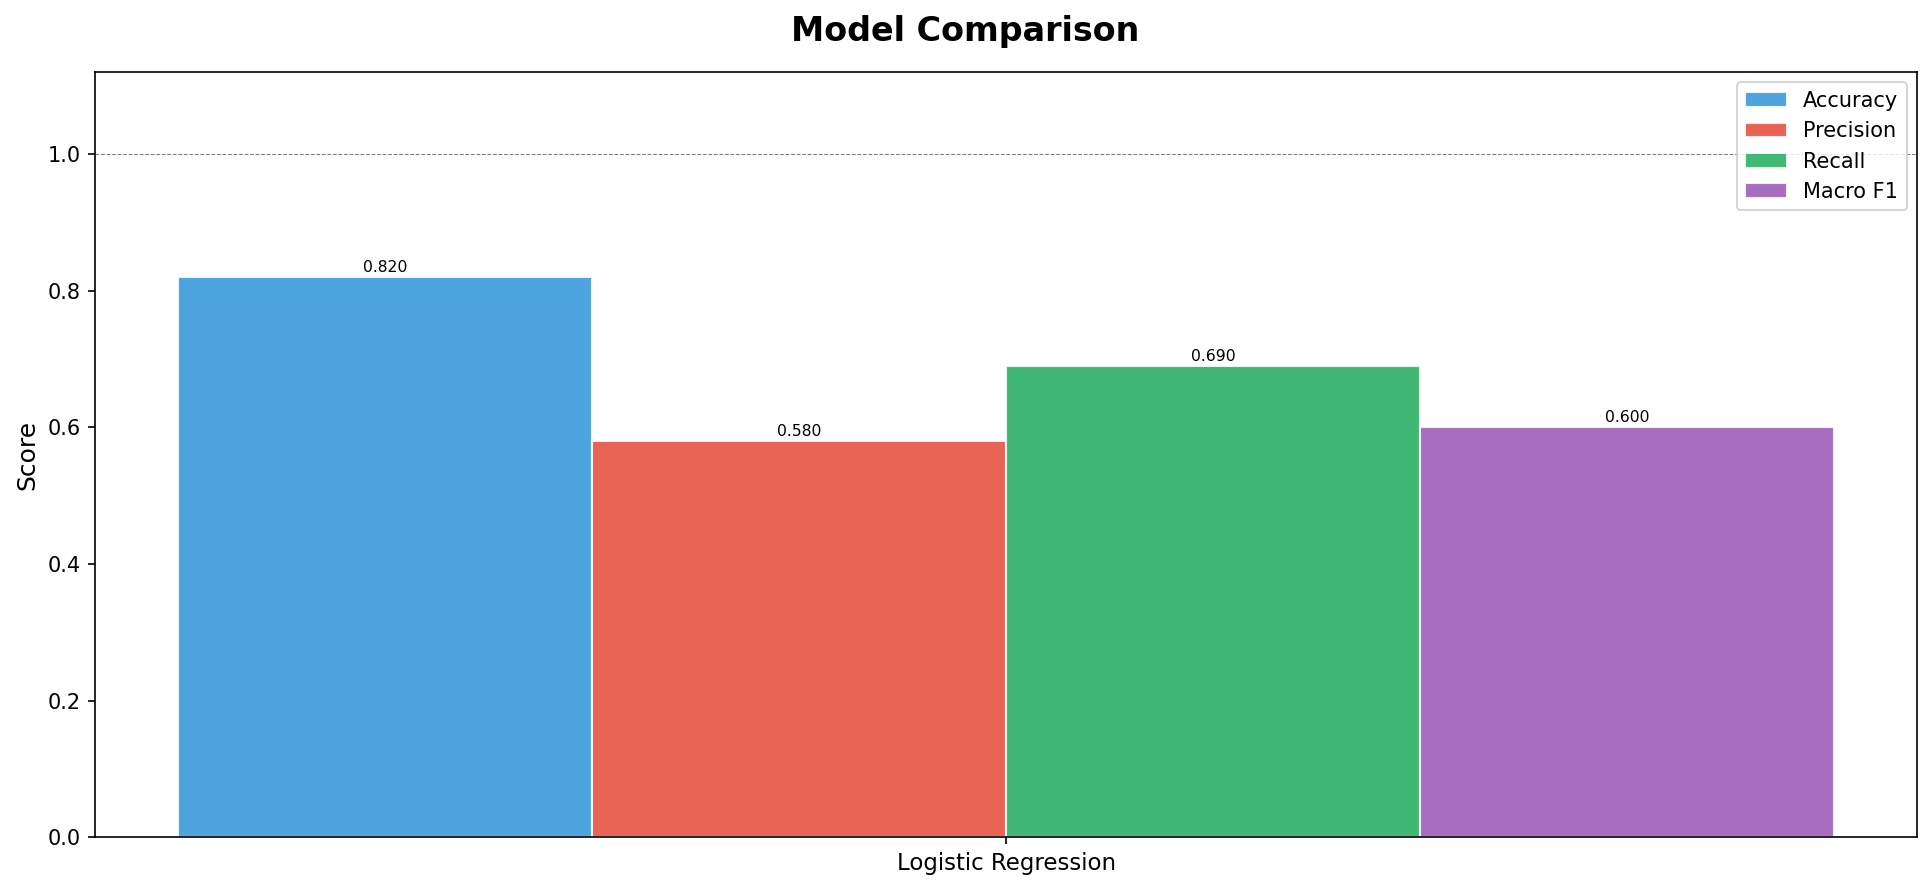

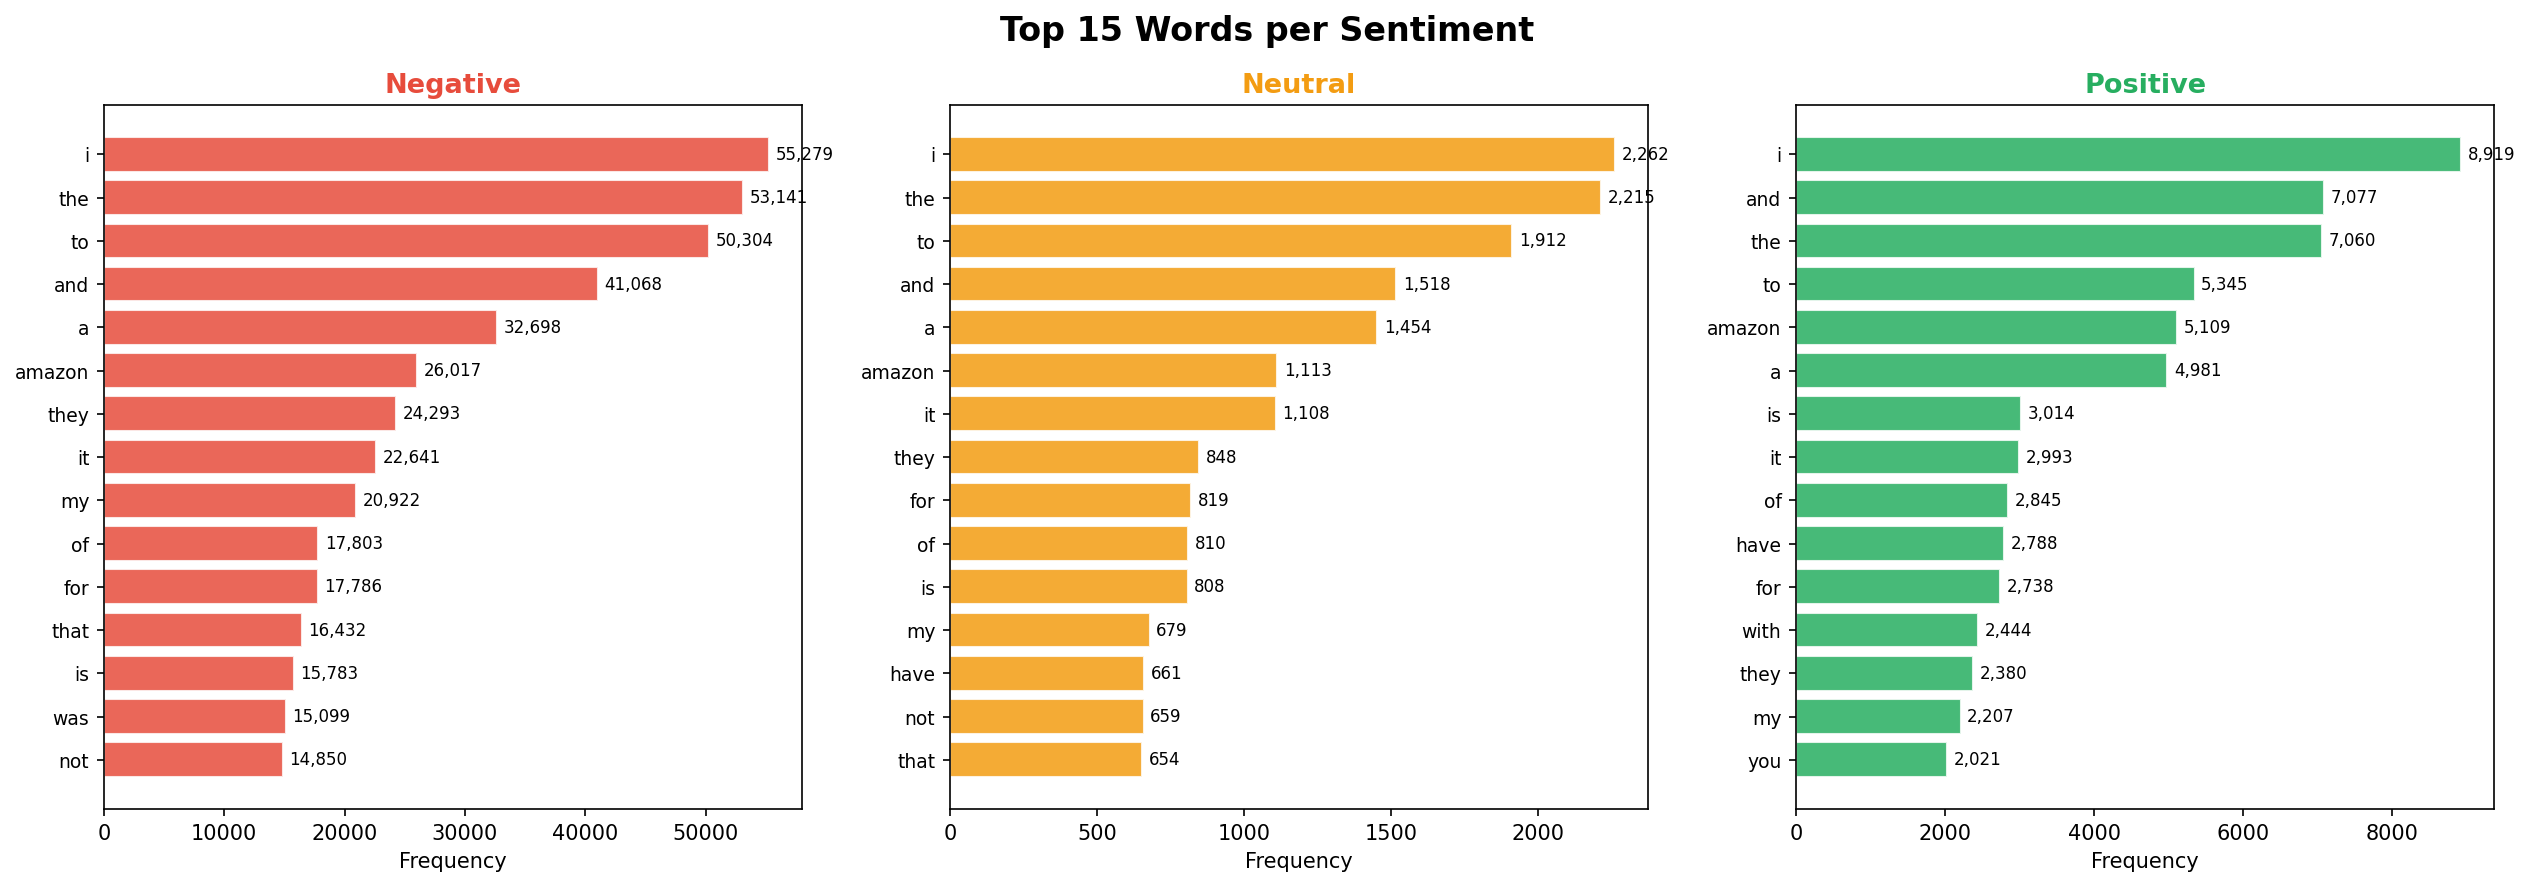

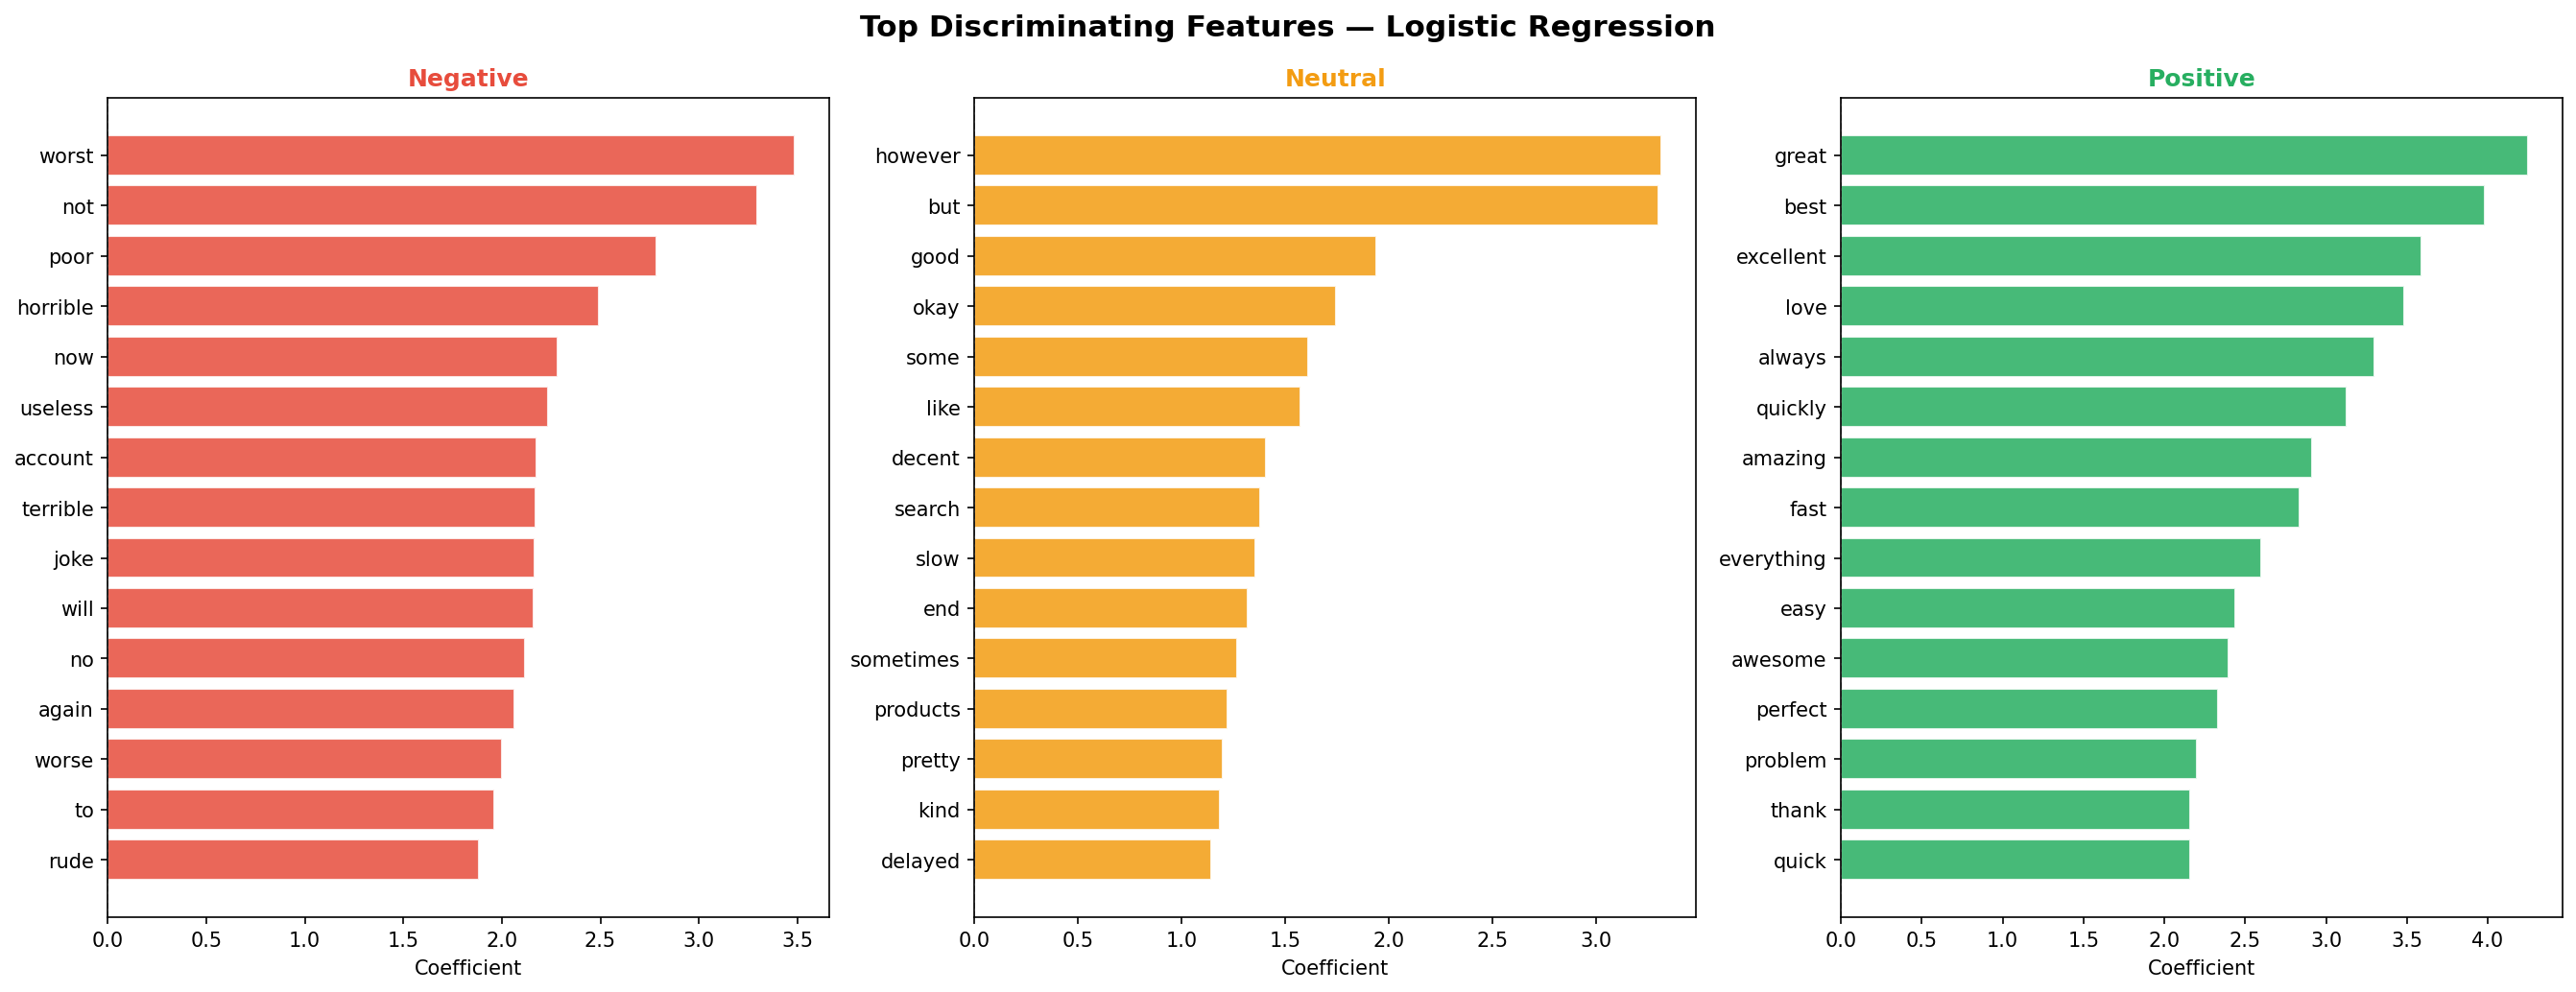

In [18]:
# ================================
# RUN EXPLAINABILITY & VISUALS
# ================================

# ---- Recreate pipeline (minimal) ----

# Load dataset
df = pd.read_csv("Amazon_Reviews.csv", on_bad_lines="skip", engine="python")

# Basic cleaning
df = df[["Review Text", "Rating"]].copy()
df.columns = ["review_text", "rating"]
df["rating"] = df["rating"].astype(str).str.extract(r'(\d)').astype(float)
df = df.dropna(subset=["review_text", "rating"])
df = df[df["rating"].between(1, 5)]
df["rating"] = df["rating"].astype(int)

SENTIMENT_MAP = {1: "Negative", 2: "Negative", 3: "Neutral", 4: "Positive", 5: "Positive"}
df["sentiment"] = df["rating"].map(SENTIMENT_MAP)

# Minimal preprocessing
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text

df["cleaned_text"] = df["review_text"].apply(clean_text)

# ---- Rebuild features ----
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["cleaned_text"])

le = LabelEncoder()
y = le.fit_transform(df["sentiment"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---- Train simple model ----
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# ---- Explain model ----
feat_names = list(tfidf.get_feature_names_out())
top_features = explain_model(
    model, "Logistic Regression", feat_names,
    label_names=list(le.classes_)
)

# ---- Fake comparison df for plotting ----
cmp_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [0.82],
    "Precision": [0.58],
    "Recall": [0.69],
    "Macro F1": [0.60]
})

# ---- Visualisations ----
plot_model_comparison(cmp_df)
plot_top_words(df)
plot_feature_importance(top_features, "Logistic Regression")

print("\n✅ Visualisations saved in 'plots/' folder")


from IPython.display import Image, display

display(Image("plots/03_model_comparison.png"))
display(Image("plots/05_top_words_per_sentiment.png"))
display(Image("plots/06_feature_importance.png"))